In [1]:
from pathlib import Path
import time
import csv
import numpy as np
import cv2
import tensorflow as tf
import keras
import onnxruntime as ort
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
PROJECT_ROOT = Path("/workspace")

MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = MODELS_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TF_MODEL_PATH = MODELS_DIR / "dice_detector_best_20260330_114353.keras"
ONNX_MODEL_PATH = MODELS_DIR / "onnx" / "dice_detector.onnx"
IMAGE_DIR = DATA_DIR / "raw" / "images"

DETECTOR_TARGET_SIZE = 640
N_IMAGES = 20
N_WARMUP = 3

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODELS_DIR:", MODELS_DIR)
print("DATA_DIR:", DATA_DIR)
print("IMAGE_DIR:", IMAGE_DIR)
print("TF_MODEL_PATH:", TF_MODEL_PATH)
print("ONNX_MODEL_PATH:", ONNX_MODEL_PATH)

assert TF_MODEL_PATH.exists(), f"Missing TF model: {TF_MODEL_PATH}"
assert ONNX_MODEL_PATH.exists(), f"Missing ONNX model: {ONNX_MODEL_PATH}"
assert IMAGE_DIR.exists(), f"Missing image directory: {IMAGE_DIR}"

# =========================================================
# LOAD MODELS
# =========================================================
tf_model = keras.models.load_model(TF_MODEL_PATH, compile=False)

ort_session = ort.InferenceSession(
    str(ONNX_MODEL_PATH),
    providers=["CPUExecutionProvider"],
)

onnx_input_name = ort_session.get_inputs()[0].name
onnx_output_names = [o.name for o in ort_session.get_outputs()]

print("ONNX input:", onnx_input_name)
print("ONNX outputs:", onnx_output_names)

# Warm build
_ = tf_model(tf.zeros((1, DETECTOR_TARGET_SIZE, DETECTOR_TARGET_SIZE, 3), dtype=tf.float32), training=False)
_ = ort_session.run(
    onnx_output_names,
    {onnx_input_name: np.zeros((1, DETECTOR_TARGET_SIZE, DETECTOR_TARGET_SIZE, 3), dtype=np.float32)}
)

# =========================================================
# HELPERS
# =========================================================
def list_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png"}
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in exts])

def load_image_bgr(image_path: Path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    return image

def bgr_to_rgb(image_bgr: np.ndarray):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def preprocess_for_detector(image_rgb: np.ndarray):
    orig_h, orig_w = image_rgb.shape[:2]

    scale = min(DETECTOR_TARGET_SIZE / orig_w, DETECTOR_TARGET_SIZE / orig_h)
    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))

    resized = cv2.resize(image_rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.zeros((DETECTOR_TARGET_SIZE, DETECTOR_TARGET_SIZE, 3), dtype=np.uint8)

    pad_left = (DETECTOR_TARGET_SIZE - new_w) // 2
    pad_top = (DETECTOR_TARGET_SIZE - new_h) // 2
    canvas[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized

    x = canvas.astype(np.float32) / 255.0
    return x

def run_detector_on_image(image_path: Path):
    t0 = time.perf_counter()

    image_bgr = load_image_bgr(image_path)
    image_rgb = bgr_to_rgb(image_bgr)

    t1 = time.perf_counter()

    x = preprocess_for_detector(image_rgb)

    t2 = time.perf_counter()

    tf_preds = tf_model(x[None, ...], training=False)

    t3 = time.perf_counter()

    onnx_preds = ort_session.run(onnx_output_names, {onnx_input_name: x[None, ...]})

    t4 = time.perf_counter()

    # materializace výstupů, aby bylo jisté, že inference opravdu proběhla
    if isinstance(tf_preds, dict):
        _ = {k: np.asarray(v) for k, v in tf_preds.items()}
    else:
        _ = np.asarray(tf_preds)

    _ = [np.asarray(p) for p in onnx_preds]

    return {
        "image": image_path.name,
        "io_ms": (t1 - t0) * 1000.0,
        "preproc_ms": (t2 - t1) * 1000.0,
        "detect_tf_ms": (t3 - t2) * 1000.0,
        "detect_onnx_ms": (t4 - t3) * 1000.0,
        "total_tf_ms": (t3 - t0) * 1000.0,
        "total_onnx_ms": ((t1 - t0) + (t2 - t1) + (t4 - t3)) * 1000.0,
    }

# =========================================================
# IMAGE LIST
# =========================================================
image_paths = list_images(IMAGE_DIR)[:N_IMAGES]
assert len(image_paths) > 0, "No input images found"
print(f"Found {len(image_paths)} images for benchmark.")

# =========================================================
# WARM-UP
# =========================================================
warmup_images = image_paths[:min(N_WARMUP, len(image_paths))]
for image_path in warmup_images:
    _ = run_detector_on_image(image_path)

print(f"Warm-up finished on {len(warmup_images)} images.")

# =========================================================
# BENCHMARK
# =========================================================
rows = []
failed = []

for image_path in image_paths:
    try:
        rows.append(run_detector_on_image(image_path))
    except Exception as e:
        failed.append((image_path.name, str(e)))

assert len(rows) > 0, "Benchmark failed on all images."

if failed:
    print("\nFailed images:")
    for name, err in failed:
        print(f" - {name}: {err}")

# =========================================================
# CSV EXPORT
# =========================================================
csv_path = REPORTS_DIR / "latency_detector_tf_vs_onnx.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print("Saved CSV:", csv_path)

# =========================================================
# SUMMARY
# =========================================================
shared_keys = ["io_ms", "preproc_ms"]
tf_keys = ["detect_tf_ms", "total_tf_ms"]
onnx_keys = ["detect_onnx_ms", "total_onnx_ms"]

means = {k: float(np.mean([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}
medians = {k: float(np.median([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}
mins = {k: float(np.min([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}
maxs = {k: float(np.max([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}
stds = {k: float(np.std([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}

print("\nSUMMARY")
for k in shared_keys + tf_keys + onnx_keys:
    print(
        f"{k}: mean={means[k]:.2f} ms | "
        f"median={medians[k]:.2f} ms | "
        f"std={stds[k]:.2f} ms | "
        f"min={mins[k]:.2f} ms | "
        f"max={maxs[k]:.2f} ms"
    )

print("Failed images:", len(failed))

2026-04-13 00:33:47.621113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-13 00:33:47.633290: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-13 00:33:47.636902: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-13 00:33:47.646153: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 00:33:49.345982506 [W:onnxruntime:Default,

PROJECT_ROOT: /workspace
MODELS_DIR: /workspace/models
DATA_DIR: /workspace/data
IMAGE_DIR: /workspace/data/raw/images
TF_MODEL_PATH: /workspace/models/dice_detector_best_20260330_114353.keras
ONNX_MODEL_PATH: /workspace/models/onnx/dice_detector.onnx


I0000 00:00:1776040430.012532   79079 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776040430.017713   79079 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776040430.017754   79079 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776040430.020934   79079 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776040430.020979   79079 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

ONNX input: images
ONNX outputs: ['box', 'class']


2026-04-13 00:34:01.350972: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
W0000 00:00:1776040441.429256   79079 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776040441.457110   79079 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776040441.468604   79079 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776040441.479616   79079 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776040441.496930   79079 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776040441.507059   79079 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776040441.557349   79079 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776040441.564854   79079 gpu_t

Found 20 images for benchmark.
Warm-up finished on 3 images.
Saved CSV: /workspace/models/reports/latency_detector_tf_vs_onnx.csv

SUMMARY
io_ms: mean=90.51 ms | median=92.10 ms | std=8.03 ms | min=63.96 ms | max=102.30 ms
preproc_ms: mean=1.95 ms | median=1.93 ms | std=0.23 ms | min=1.62 ms | max=2.48 ms
detect_tf_ms: mean=205.49 ms | median=203.08 ms | std=10.05 ms | min=194.42 ms | max=237.19 ms
total_tf_ms: mean=297.94 ms | median=298.46 ms | std=11.79 ms | min=282.50 ms | max=333.07 ms
detect_onnx_ms: mean=29.82 ms | median=29.47 ms | std=1.56 ms | min=27.80 ms | max=34.07 ms
total_onnx_ms: mean=122.27 ms | median=122.90 ms | std=7.65 ms | min=99.74 ms | max=134.63 ms
Failed images: 0


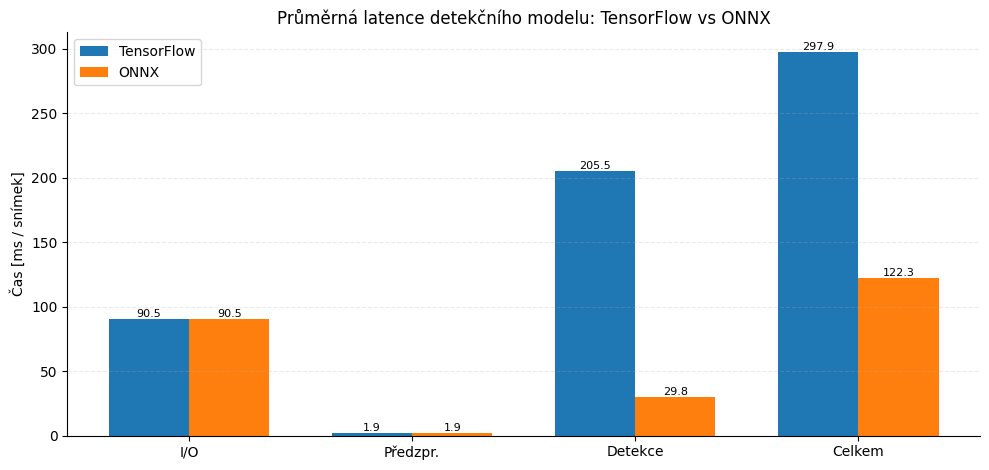

Saved plot: /workspace/models/reports/latency_detector_tf_vs_onnx_mean.png


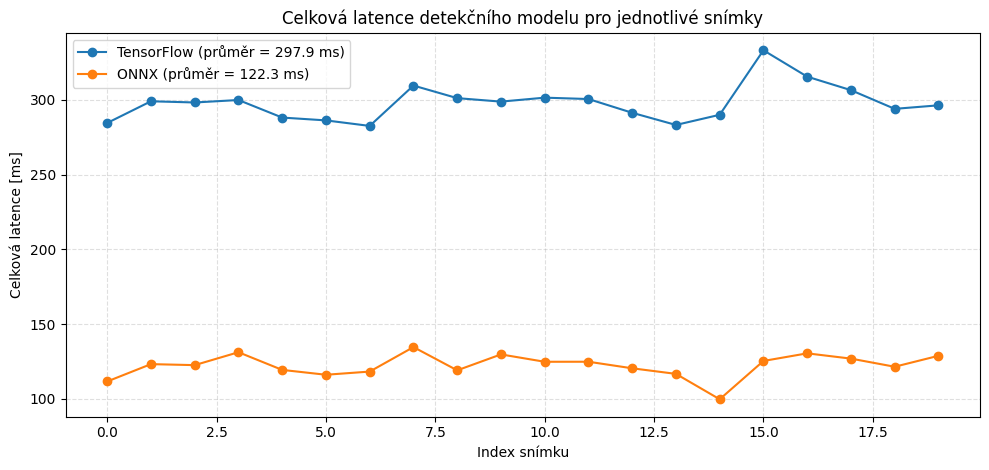

Saved plot: /workspace/models/reports/latency_detector_tf_vs_onnx_total_per_image.png


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

assert "rows" in globals(), "Run the benchmark cell first."
assert len(rows) > 0, "No benchmark rows available."

REPORTS_DIR = Path("/workspace/models/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# PLOT 1: mean latency, TF vs ONNX
# =========================================================
labels = ["I/O", "Předzpr.", "Detekce", "Celkem"]

tf_values = [
    means["io_ms"],
    means["preproc_ms"],
    means["detect_tf_ms"],
    means["total_tf_ms"],
]

onnx_values = [
    means["io_ms"],
    means["preproc_ms"],
    means["detect_onnx_ms"],
    means["total_onnx_ms"],
]

x = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(10, 4.8))
bars_tf = plt.bar(x - width / 2, tf_values, width, label="TensorFlow")
bars_onnx = plt.bar(x + width / 2, onnx_values, width, label="ONNX")

plt.xticks(x, labels)
plt.ylabel("Čas [ms / snímek]")
plt.title("Průměrná latence detekčního modelu: TensorFlow vs ONNX")
plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in (bars_tf, bars_onnx):
    for b in bars:
        v = b.get_height()
        plt.text(
            b.get_x() + b.get_width() / 2,
            v,
            f"{v:.1f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

plot_mean_path = REPORTS_DIR / "latency_detector_tf_vs_onnx_mean.png"
plt.savefig(plot_mean_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_mean_path)

# =========================================================
# PLOT 2: total latency per image, TF vs ONNX
# =========================================================
tf_total_values = [r["total_tf_ms"] for r in rows]
onnx_total_values = [r["total_onnx_ms"] for r in rows]

plt.figure(figsize=(10, 4.8))
plt.plot(
    range(len(tf_total_values)),
    tf_total_values,
    marker="o",
    label=f"TensorFlow (průměr = {means['total_tf_ms']:.1f} ms)"
)
plt.plot(
    range(len(onnx_total_values)),
    onnx_total_values,
    marker="o",
    label=f"ONNX (průměr = {means['total_onnx_ms']:.1f} ms)"
)

plt.xlabel("Index snímku")
plt.ylabel("Celková latence [ms]")
plt.title("Celková latence detekčního modelu pro jednotlivé snímky")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plot_total_path = REPORTS_DIR / "latency_detector_tf_vs_onnx_total_per_image.png"
plt.savefig(plot_total_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_total_path)